# CA1 – Numeric Variables
**Moustafa Almohamed – X00228076**

## 1. Setup and Data Loading

In [3]:
# libraries for tables and charts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset (columns are separated by ";")
df = pd.read_csv("data/bank-additional-full.csv", sep=";")
print(df.shape)  # (rows, columns)
df.head()        # first 5 rows

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Exploratory Data Analysis (Numeric Variables)
These are the 9 numeric input variables analysed in this section.

In [4]:
# list of the 9 numeric input columns
num_cols = ["age", "campaign", "pdays", "previous",
            "emp.var.rate", "cons.price.idx", "cons.conf.idx",
            "euribor3m", "nr.employed"]
df[num_cols].head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0


### 2.1 Summary Statistics

In [5]:
# summary statistics for the numeric columns
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


All 9 numeric columns have 41,188 values, so there are no empty (NaN) values. Age ranges from 17 to 98, with an average of about 40, which looks realistic. For campaign, the median is 2 calls, but some clients were called up to 56 times, so there may be outliers. In pdays, the value 999 means the client was never contacted before, so it is not a real number of days and should be recoded. Most clients also have 0 previous contacts. Finally, the economic columns have very different scales, so the data will need to be scaled before using PCA.

### 2.2 Distributions (Histograms)
Histograms show how the values of each numeric variable are spread out.

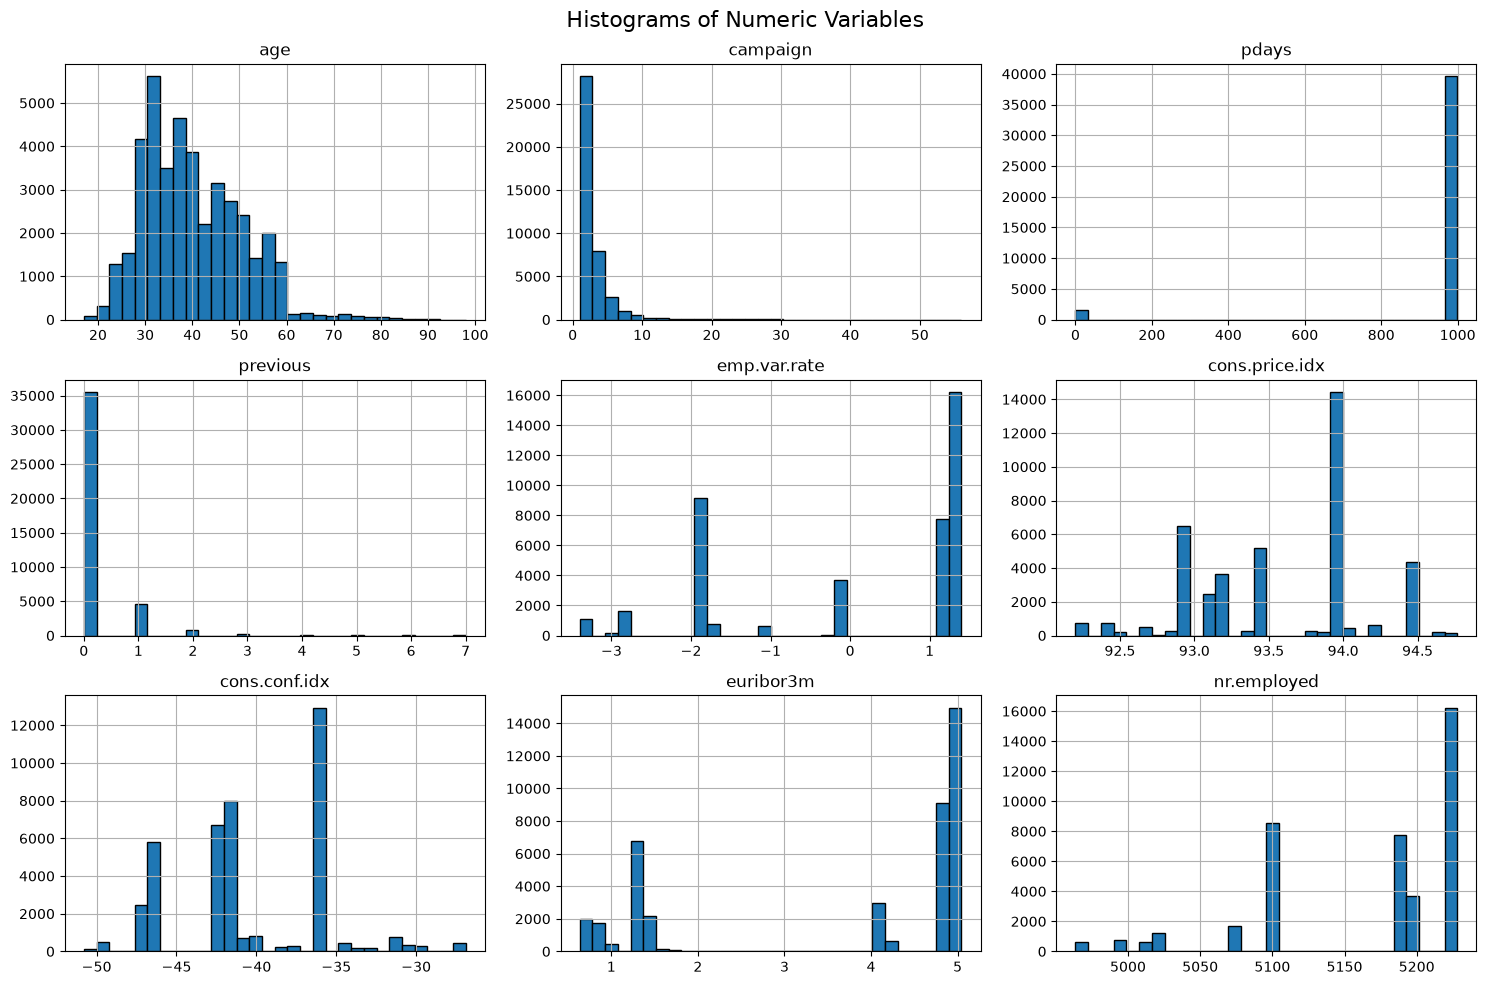

In [6]:
# histogram for each numeric column (3 rows x 3 columns of charts)
df[num_cols].hist(bins=30, figsize=(15, 10), edgecolor="black")
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()

### 2.3 Outliers (Box Plots)
Box plots show the middle 50% of values (the box) and mark unusual values as dots.

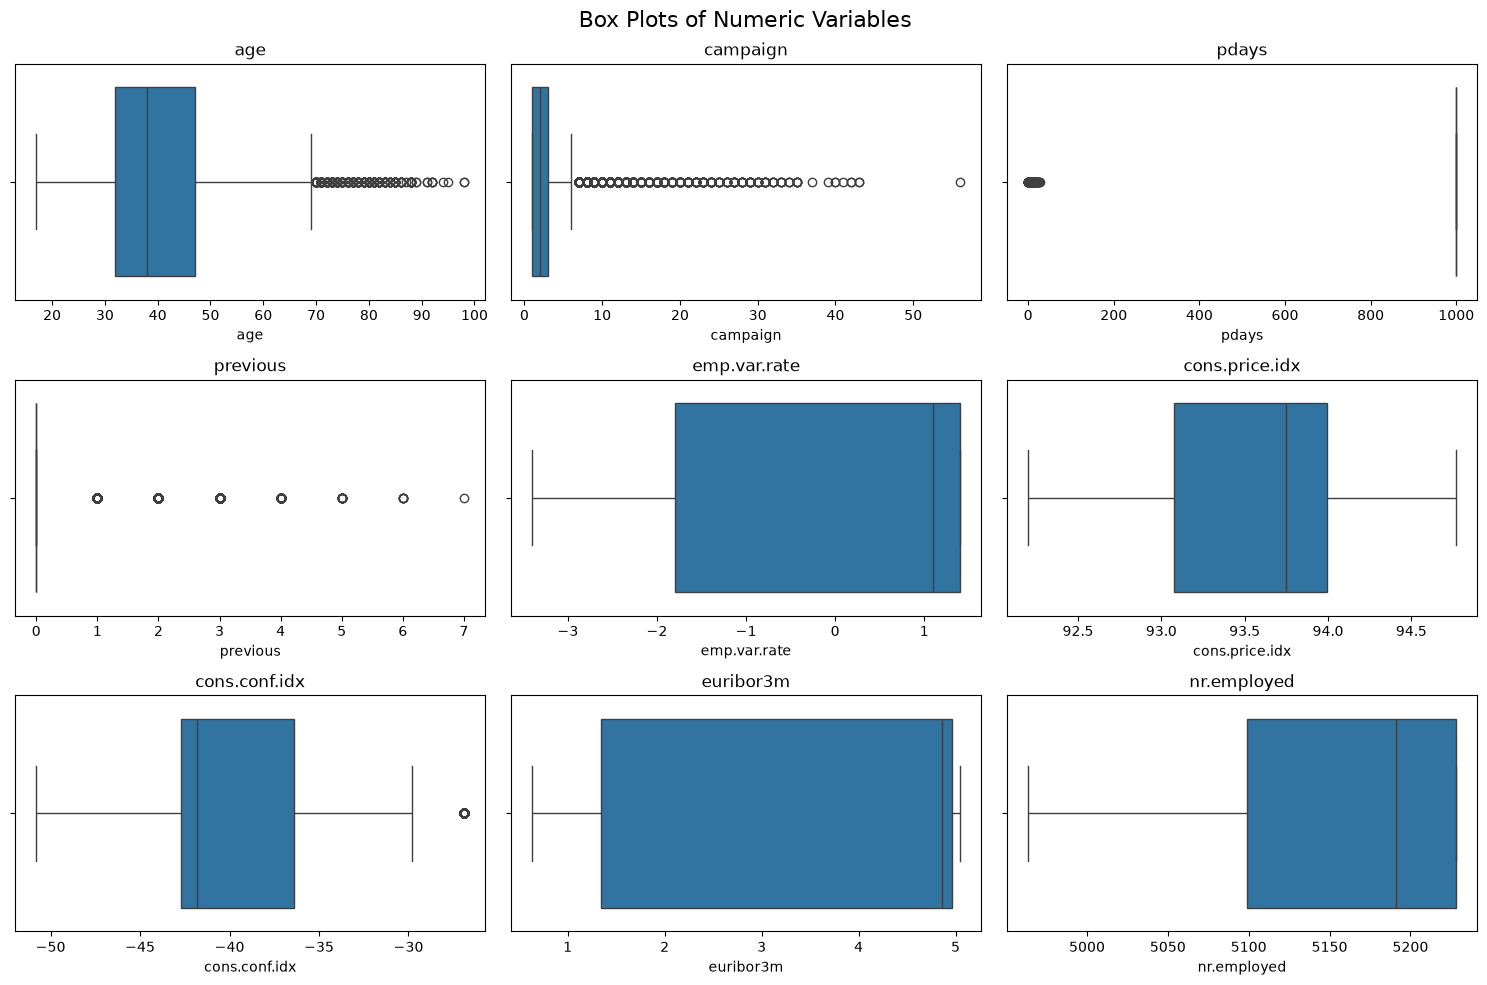

In [7]:
# one box plot per numeric column (separate charts because the scales are very different)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle("Box Plots of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretation:**
- `age` has upper outliers (about 70–98). These are realistic older clients, not data errors.
- `campaign` has many outliers (from about 7 up to 56 calls). This is the most important outlier problem and suggests capping or a log transformation.
- In `pdays` the box collapses at 999, so the real day values (0–27) are wrongly shown as outliers. This confirms that 999 is a code and must be recoded.
- In `previous` every value above 0 is flagged, simply because most clients have 0. These are valid values, not errors.
- `cons.conf.idx` has one outlier (about −27), which is a real monthly economic value.
- Not every box-plot outlier is an error; each one must be judged in context before deciding how to treat it.

### 2.4 Correlation Between Numeric Variables
The heatmap shows how strongly each pair of numeric variables moves together (from -1 to +1).

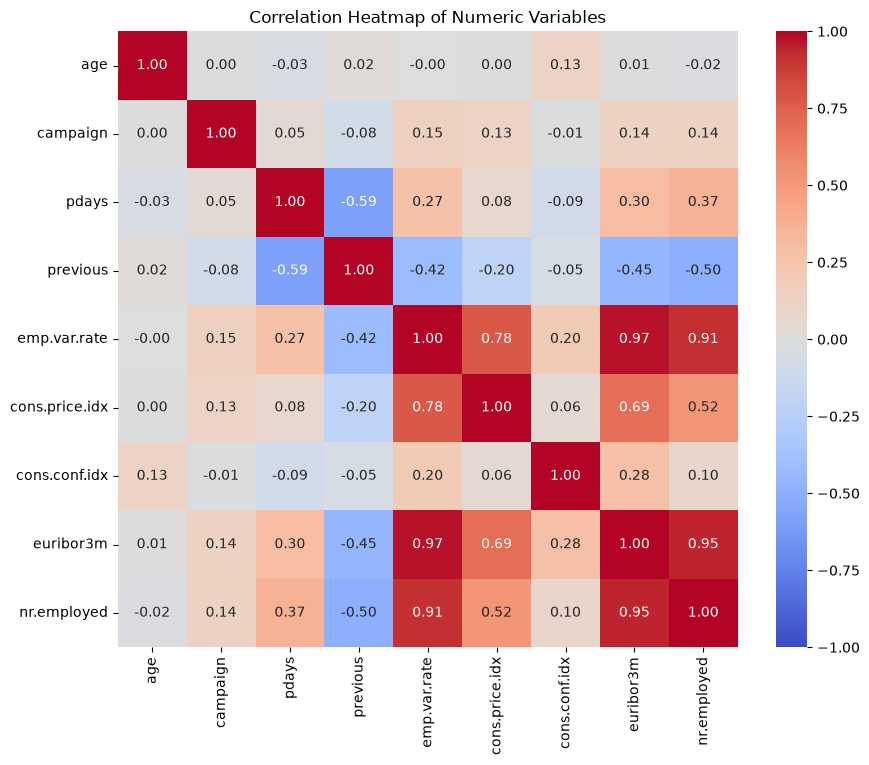

In [8]:
# correlation between every pair of numeric columns
corr = df[num_cols].corr()

# draw it as a coloured grid with the numbers shown
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

### 2.5 Scatter Plot
Checking visually how the two most correlated economic variables move together.

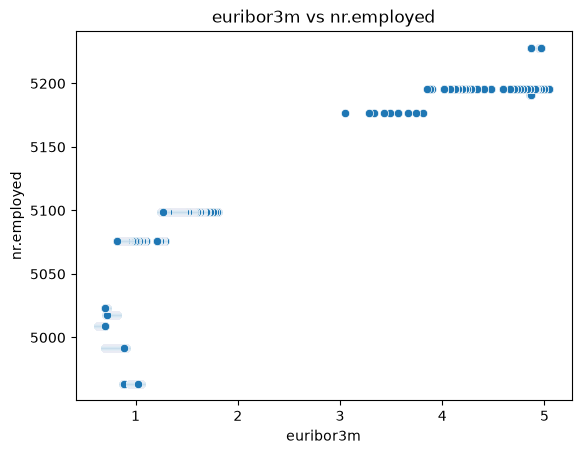

In [15]:
# scatter plot of the two most correlated economic variables
sns.scatterplot(x="euribor3m", y="nr.employed", data=df)
plt.title("euribor3m vs nr.employed")
plt.show()

**Interpretation:** The scatter plot confirms the strong positive relationship between `euribor3m` and `nr.employed` (r = 0.95): higher interest rates appear together with higher employment. The points form horizontal bands because `nr.employed` takes only 11 distinct values, recorded per time period rather than per client, so many points overlap. This visual redundancy supports checking these variables with VIF and combining them with PCA later.

## 3. Data Quality and Cleaning
### 3.1 Duplicate Rows
Checking whether any rows are exact copies of another row.

In [9]:
# count rows that are exact copies of an earlier row
print("Duplicate rows:", df.duplicated().sum())

# show the duplicated rows next to their copies
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

Duplicate rows: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


In [10]:
# remove exact duplicate rows (keep the first copy)
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 41176


**Interpretation:** 12 rows (0.03%) were exact duplicates across all 21 columns, including call duration in seconds, so they are very likely repeated records rather than different clients. They were removed, leaving 41,176 rows.

### 3.2 Data Types
Checking that each numeric variable is stored as a number.

In [11]:
# data type and number of different values for each numeric column
pd.DataFrame({"dtype": df[num_cols].dtypes,
              "unique_values": df[num_cols].nunique()})

,dtype,unique_values
age,int64,78
campaign,int64,42
pdays,int64,27
previous,int64,8
emp.var.rate,float64,10
cons.price.idx,float64,26
cons.conf.idx,float64,26
euribor3m,float64,316
nr.employed,float64,11


**Interpretation:** All numeric variables are stored with correct types: counts and ages as integers (`int64`) and economic indicators as decimals (`float64`), so no type conversion is needed. The economic indicators have very few distinct values (10–26, except `euribor3m` with 316) because they are recorded per time period rather than per client. `pdays` has 27 distinct values, one of which is the 999 code.

### 3.3 Outliers (IQR Method)
Counting values outside 1.5 × IQR to decide whether they are errors or valid extreme values.

In [12]:
# IQR rule: values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are outliers
q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# count outliers per column
n_out = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()
pd.DataFrame({"lower_limit": lower, "upper_limit": upper,
              "outliers": n_out, "percent": (n_out / len(df) * 100).round(2)})

,lower_limit,upper_limit,outliers,percent
age,9.5000,69.5000,468,1.14
campaign,-2.0000,6.0000,2406,5.84
pdays,999.0000,999.0000,1515,3.68
previous,0.0000,0.0000,5625,13.66
emp.var.rate,-6.6000,6.2000,0,0.00
cons.price.idx,91.6965,95.3725,0,0.00
cons.conf.idx,-52.1500,-26.9500,446,1.08
euribor3m,-4.0815,10.3865,0,0.00
nr.employed,4905.6000,5421.6000,0,0.00


### 3.4 Recoding `pdays` (999 code)
`pdays = 999` means the client was never contacted before. It is a code, not a real number of days, so it is replaced with a yes/no indicator.

In [13]:
# new yes/no column: 1 = contacted in a previous campaign, 0 = never (999)
df["prev_contacted"] = (df["pdays"] != 999).astype(int)
print(df["prev_contacted"].value_counts())

# remove the original pdays column and update the numeric list
df = df.drop(columns="pdays")
num_cols.remove("pdays")
print("Numeric columns now:", num_cols)

prev_contacted
0    39661
1     1515
Name: count, dtype: int64
Numeric columns now: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


**Interpretation:** 999 was replaced by a binary indicator `prev_contacted` (1 = contacted in a previous campaign, 0 = never). Only 1,515 clients (3.7%) had been contacted before, while 39,661 had the 999 code. The original `pdays` column was removed, as its exact day values applied to very few clients and the 999 code would mislead later steps such as scaling and PCA. The number of previous contacts is still kept in `previous`. This is a fixed rule (not learned from the data), so it does not cause data leakage.